# Machine Learning Assignment - 2

## Binary Classification of Spam Emails using Machine Learning

### Models Implemented

1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Gaussian Naive Bayes Classifier
5. Random Forest Classifier

### Evaluation Metrics

1. Accuracy
2. AUC Score
3. Precision
4. Recall
5. F1 Score
6. Matthews Correlation Coefficient (MCC)

### Dataset

UCI Spambase Dataset

## 1. Problem Statement

The objective of this assignment is to develop and compare multiple
machine learning classification algorithms for identifying whether an
email is spam or non-spam.

The problem is formulated as a binary classification problem where:

- 0 represents a non-spam email
- 1 represents a spam email

The following classification algorithms will be implemented and evaluated:

- Logistic Regression
- Decision Tree Classifier
- K-Nearest Neighbor Classifier
- Gaussian Naive Bayes Classifier
- Random Forest Classifier

The performance of each model will be evaluated using Accuracy, AUC,
Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

In [175]:
# ============================================================
# Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

import joblib
import os

print("All libraries imported successfully.")

All libraries imported successfully.


In [176]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv(
    "../data/spambase.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (4601, 58)


In [177]:
# ============================================================
# Inspect Dataset Columns
# ============================================================

print("Number of columns:", len(df.columns))

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2d}. {column}")

Number of columns: 58

Column names:
 1. word_freq_make
 2. word_freq_address
 3. word_freq_all
 4. word_freq_3d
 5. word_freq_our
 6. word_freq_over
 7. word_freq_remove
 8. word_freq_internet
 9. word_freq_order
10. word_freq_mail
11. word_freq_receive
12. word_freq_will
13. word_freq_people
14. word_freq_report
15. word_freq_addresses
16. word_freq_free
17. word_freq_business
18. word_freq_email
19. word_freq_you
20. word_freq_credit
21. word_freq_your
22. word_freq_font
23. word_freq_000
24. word_freq_money
25. word_freq_hp
26. word_freq_hpl
27. word_freq_george
28. word_freq_650
29. word_freq_lab
30. word_freq_labs
31. word_freq_telnet
32. word_freq_857
33. word_freq_data
34. word_freq_415
35. word_freq_85
36. word_freq_technology
37. word_freq_1999
38. word_freq_parts
39. word_freq_pm
40. word_freq_direct
41. word_freq_cs
42. word_freq_meeting
43. word_freq_original
44. word_freq_project
45. word_freq_re
46. word_freq_edu
47. word_freq_table
48. word_freq_conference
49. char_freq

In [178]:
# ============================================================
# Preview Dataset
# ============================================================

df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [179]:
# ============================================================
# Dataset Information
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [180]:
# ============================================================
# Statistical Summary
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


In [181]:
# ============================================================
# Missing Value Analysis
# ============================================================

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

In [182]:
# ============================================================
# Duplicate Record Analysis
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 391


In [183]:
# ============================================================
# Display Last Column
# ============================================================

print("Last column name:", df.columns[-1])
print(df["spam"].value_counts())

Last column name: spam
spam
0    2788
1    1813
Name: count, dtype: int64


In [184]:
# ============================================================
# Target Variable Distribution
# ============================================================

print(df["spam"].value_counts())

print("\nPercentage distribution:")
print(
    df["spam"].value_counts(normalize=True) * 100
)

spam
0    2788
1    1813
Name: count, dtype: int64

Percentage distribution:
spam
0    60.595523
1    39.404477
Name: proportion, dtype: float64


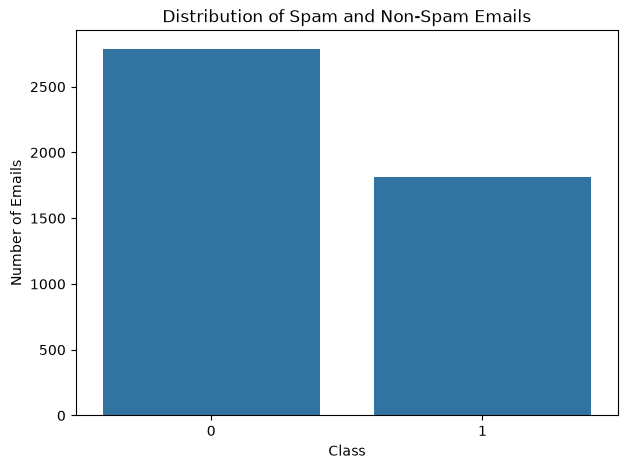

In [185]:
# ============================================================
# Target Distribution Visualization
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="spam"
)

plt.title("Distribution of Spam and Non-Spam Emails")
plt.xlabel("Class")
plt.ylabel("Number of Emails")

plt.show()

## Dataset Observations

The Spambase dataset is a binary classification dataset where the target
variable `spam` indicates whether an email is classified as spam or
non-spam.

- `spam = 0` represents a non-spam email.
- `spam = 1` represents a spam email.

The dataset contains 4,601 instances and 57 input features. Therefore,
the dataset satisfies the minimum dataset requirements specified in the
assignment.

The target distribution is examined before model training to understand
whether there is any class imbalance.

In [186]:
# ============================================================
# Separate Features and Target
# ============================================================

X = df.drop("spam", axis=1)
y = df["spam"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4601, 57)
Target vector shape: (4601,)


In [187]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (3680, 57)
Testing data shape: (921, 57)

Training target distribution:
spam
0    0.605978
1    0.394022
Name: proportion, dtype: float64

Testing target distribution:
spam
0    0.605863
1    0.394137
Name: proportion, dtype: float64


In [188]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

Training data scaled successfully.
Testing data scaled successfully.


In [189]:
# ============================================================
# Investigate Duplicate Records
# ============================================================

duplicate_rows = df[df.duplicated(keep=False)]

print("Total rows involved in duplication:",
      len(duplicate_rows))

print("Number of unique duplicated records:",
      duplicate_rows.drop_duplicates().shape[0])

Total rows involved in duplication: 571
Number of unique duplicated records: 180


In [190]:
# ============================================================
# Check Duplicate Records for Conflicting Target Labels
# ============================================================

duplicate_groups = (
    df.groupby(
        list(df.columns[:-1])
    )["spam"]
    .nunique()
)

conflicting_duplicates = duplicate_groups[
    duplicate_groups > 1
]

print(
    "Number of feature combinations with conflicting labels:",
    len(conflicting_duplicates)
)

Number of feature combinations with conflicting labels: 3


In [191]:
# ============================================================
# Inspect Conflicting Duplicate Records
# ============================================================

feature_columns = df.columns[:-1].tolist()

conflicting_records = (
    df.groupby(feature_columns, dropna=False)
      .filter(lambda group: group["spam"].nunique() > 1)
)

display(conflicting_records)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
63,0.00,0.34,0.00,0.0,0.68,0.00,0.68,0.00,0.0,0.34,...,0.000,0.000,0.0,0.048,0.048,0.0,1.411,15,96,1
148,0.36,0.00,1.09,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.063,0.126,0.0,0.063,0.126,0.0,2.562,35,123,1
478,0.00,0.00,0.00,0.0,0.00,0.05,0.00,0.34,0.0,0.00,...,0.283,0.107,0.0,0.000,0.053,0.0,1.864,32,910,1
1985,0.36,0.00,1.09,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.063,0.126,0.0,0.063,0.126,0.0,2.562,35,123,0
3108,0.00,0.34,0.00,0.0,0.68,0.00,0.68,0.00,0.0,0.34,...,0.000,0.000,0.0,0.048,0.048,0.0,1.411,15,96,0
3213,0.00,0.00,0.00,0.0,0.00,0.05,0.00,0.34,0.0,0.00,...,0.283,0.107,0.0,0.000,0.053,0.0,1.864,32,910,0


In [192]:
# ============================================================
# Count Conflicting Duplicate Records
# ============================================================

print(
    "Number of rows involved in conflicting duplicates:",
    len(conflicting_records)
)

print("\nTarget distribution within conflicting records:")
print(conflicting_records["spam"].value_counts())

Number of rows involved in conflicting duplicates: 6

Target distribution within conflicting records:
spam
1    3
0    3
Name: count, dtype: int64


In [193]:
# ============================================================
# Remove Conflicting Duplicate Records
# ============================================================

feature_columns = df.columns[:-1].tolist()

# Identify feature combinations having more than one target label
conflicting_groups = (
    df.groupby(feature_columns, dropna=False)["spam"]
      .nunique()
)

conflicting_groups = conflicting_groups[
    conflicting_groups > 1
]

# Identify rows belonging to those conflicting groups
conflicting_records = (
    df.groupby(feature_columns, dropna=False)
      .filter(lambda group: group["spam"].nunique() > 1)
)

print("Rows with conflicting labels:",
      len(conflicting_records))

# Remove conflicting records
df_clean = df.drop(conflicting_records.index)

print("Dataset shape after removing conflicting records:",
      df_clean.shape)

Rows with conflicting labels: 6
Dataset shape after removing conflicting records: (4595, 58)


In [194]:
# ============================================================
# Remove Exact Duplicate Records
# ============================================================

duplicates_before = df_clean.duplicated().sum()

print("Exact duplicate rows before removal:",
      duplicates_before)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing exact duplicates:",
      df_clean.shape)

Exact duplicate rows before removal: 391
Dataset shape after removing exact duplicates: (4204, 58)


In [195]:
# ============================================================
# Validate Cleaned Dataset
# ============================================================

print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nExact duplicate rows:")
print(df_clean.duplicated().sum())

print("\nTarget distribution:")
print(df_clean["spam"].value_counts())

print("\nTarget percentage distribution:")
print(
    (df_clean["spam"].value_counts(normalize=True) * 100).round(2)
)

Final dataset shape: (4204, 58)

Missing values:
0

Exact duplicate rows:
0

Target distribution:
spam
0    2528
1    1676
Name: count, dtype: int64

Target percentage distribution:
spam
0    60.13
1    39.87
Name: proportion, dtype: float64


## Data Cleaning and Duplicate Handling

The dataset initially contained 4,601 observations and 58 columns,
including 57 input features and one binary target variable (`spam`).

The data quality analysis identified:

- No missing values.
- 391 exact duplicate rows.
- 180 unique feature combinations involved in duplicate groups.
- 3 feature combinations with conflicting target labels, involving
  6 observations.

Exact duplicate observations were removed to prevent the same feature
vector from potentially appearing in both the training and testing
datasets, which could lead to data leakage.

The 6 observations with conflicting target labels were also removed.
These observations represented identical feature vectors associated
with both spam and non-spam labels, making their target classification
ambiguous.

After this preprocessing, the resulting dataset contains 4,204
observations and 57 input features.

## Feature and Target Separation

The target variable is `spam`, which represents the class of the email:

- `0` → Non-spam
- `1` → Spam

All remaining 57 columns are used as input features (`X`).

Therefore:

- `X` contains 4,204 observations and 57 features.
- `y` contains 4,204 target values.

In [196]:
# ============================================================
# Separate Features and Target
# ============================================================

X = df_clean.drop("spam", axis=1)
y = df_clean["spam"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (4204, 57)
Target vector shape: (4204,)

Feature columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'c

## Train-Test Split

The cleaned dataset is divided into training and testing subsets.

An 80:20 split is used:

- 80% of the observations are used for training.
- 20% are reserved for final model evaluation.

Stratified sampling is used so that the proportion of spam and
non-spam emails remains approximately the same in both subsets.

A fixed random state of 42 is used to make the experiment reproducible.

In [197]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

Training feature matrix: (3363, 57)
Testing feature matrix: (841, 57)

Training target distribution:
spam
0    2022
1    1341
Name: count, dtype: int64
spam
0    60.12
1    39.88
Name: proportion, dtype: float64

Testing target distribution:
spam
0    506
1    335
Name: count, dtype: int64
spam
0    60.17
1    39.83
Name: proportion, dtype: float64


## Feature Scaling

Feature scaling is applied using `StandardScaler`.

Standardization transforms each feature approximately to:

- Mean = 0
- Standard deviation = 1

The scaler is fitted only on the training data and then applied to
both the training and testing data.

This prevents information from the test set from influencing the
preprocessing stage and avoids data leakage.

Scaling is particularly important for algorithms such as Logistic
Regression and K-Nearest Neighbors because their behavior is affected
by the scale of the input features.

In [198]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the already-fitted scaler to test data
X_test_scaled = scaler.transform(X_test)

print("Original training shape:", X_train.shape)
print("Scaled training shape:", X_train_scaled.shape)

print("\nOriginal testing shape:", X_test.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Original training shape: (3363, 57)
Scaled training shape: (3363, 57)

Original testing shape: (841, 57)
Scaled testing shape: (841, 57)


## Model Evaluation Metrics

Each classification model will be evaluated using the following metrics:

1. Accuracy
2. AUC Score
3. Precision
4. Recall
5. F1 Score
6. Matthews Correlation Coefficient (MCC)

The same evaluation function is used for all five models so that the
performance comparison is consistent.

In [199]:
# ============================================================
# Model Evaluation Function
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Calculate the six evaluation metrics required for the assignment.
    
    Parameters
    ----------
    model_name : str
        Name of the model.
        
    y_true : array-like
        Actual target values.
        
    y_pred : array-like
        Predicted class labels.
        
    y_prob : array-like
        Predicted probability for the positive class (spam = 1).
        
    Returns
    -------
    dict
        Dictionary containing all evaluation metrics.
    """

    accuracy = accuracy_score(y_true, y_pred)

    auc = roc_auc_score(y_true, y_prob)

    precision = precision_score(y_true, y_pred, zero_division=0)

    recall = recall_score(y_true, y_pred, zero_division=0)

    f1 = f1_score(y_true, y_pred, zero_division=0)

    mcc = matthews_corrcoef(y_true, y_pred)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    }

In [200]:
# ============================================================
# Store Model Results
# ============================================================

results = []

# 11. Logistic Regression

Logistic Regression is a supervised classification algorithm used to
predict the probability that an observation belongs to a particular
class.

Since the Spambase problem is binary classification, Logistic Regression
is suitable for predicting:

- 0 → Non-spam
- 1 → Spam

The scaled training and testing datasets are used because Logistic
Regression can benefit from features being on comparable scales.

In [201]:
# ============================================================
# Model 1 - Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Predict class labels
logistic_pred = logistic_model.predict(X_test_scaled)

# Predict probability of positive class (spam = 1)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

results.append(logistic_results)

print("Logistic Regression completed.")
print(logistic_results)

Logistic Regression completed.
{'Model': 'Logistic Regression', 'Accuracy': 0.9239001189060642, 'AUC': 0.9720665447466226, 'Precision': 0.9044776119402985, 'Recall': 0.9044776119402985, 'F1 Score': 0.9044776119402985, 'MCC': 0.841236505220931}


# 12. Decision Tree Classifier

A Decision Tree is a tree-based classification algorithm that recursively
splits the data according to feature values.

Unlike distance-based algorithms, Decision Trees do not require feature
scaling because their decisions are based on feature thresholds.

Therefore, the original unscaled training and testing features are used.

In [202]:
# ============================================================
# Model 2 - Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree_model.fit(X_train, y_train)

# Predict class labels
decision_tree_pred = decision_tree_model.predict(X_test)

# Predict probability of positive class
decision_tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluate
decision_tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_pred,
    decision_tree_prob
)

results.append(decision_tree_results)

print("Decision Tree completed.")
print(decision_tree_results)

Decision Tree completed.
{'Model': 'Decision Tree', 'Accuracy': 0.9227110582639715, 'AUC': 0.9186213202760899, 'Precision': 0.9066265060240963, 'Recall': 0.8985074626865671, 'F1 Score': 0.9025487256371814, 'MCC': 0.8385347550115674}


# 13. K-Nearest Neighbors Classifier

K-Nearest Neighbors (KNN) classifies an observation based on the classes
of its nearest neighboring observations.

Since KNN relies on distance calculations, feature scaling is important.
The standardized training and testing datasets are therefore used.

The value of `k` represents the number of neighboring observations used
to determine the prediction.

In [203]:
# ============================================================
# Model 3 - K-Nearest Neighbors
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model
knn_model.fit(X_train_scaled, y_train)

# Predict class labels
knn_pred = knn_model.predict(X_test_scaled)

# Predict probability of positive class
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
knn_results = evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_pred,
    knn_prob
)

results.append(knn_results)

print("KNN completed.")
print(knn_results)

KNN completed.
{'Model': 'K-Nearest Neighbors', 'Accuracy': 0.9167657550535078, 'AUC': 0.9653914223349656, 'Precision': 0.9027355623100304, 'Recall': 0.8865671641791045, 'F1 Score': 0.8945783132530121, 'MCC': 0.8259173570148083}


# 14. Gaussian Naive Bayes Classifier

Naive Bayes is a probabilistic classification algorithm based on Bayes'
theorem.

Gaussian Naive Bayes assumes that the continuous input features follow
a Gaussian (normal) distribution within each class.

The model assumes conditional independence between the features given
the class.

Gaussian Naive Bayes is suitable for the numerical features in the
Spambase dataset.

In [204]:
# ============================================================
# Model 4 - Gaussian Naive Bayes
# ============================================================

from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB()

# Train the model
naive_bayes_model.fit(X_train, y_train)

# Predict class labels
naive_bayes_pred = naive_bayes_model.predict(X_test)

# Predict probability of positive class
naive_bayes_prob = naive_bayes_model.predict_proba(X_test)[:, 1]

# Evaluate
naive_bayes_results = evaluate_model(
    "Gaussian Naive Bayes",
    y_test,
    naive_bayes_pred,
    naive_bayes_prob
)

results.append(naive_bayes_results)

print("Gaussian Naive Bayes completed.")
print(naive_bayes_results)

Gaussian Naive Bayes completed.
{'Model': 'Gaussian Naive Bayes', 'Accuracy': 0.8252080856123662, 'AUC': 0.9498230192908972, 'Precision': 0.7034632034632035, 'Recall': 0.9701492537313433, 'F1 Score': 0.8155583437892095, 'MCC': 0.6881476326437402}


# 15. Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple
Decision Trees.

Each tree is trained using a random subset of the training observations
and features. The final classification is obtained by combining the
predictions of the individual trees.

Random Forest is an ensemble model and therefore satisfies the ensemble
model requirement of the assignment.

Feature scaling is not required because Random Forest is based on
Decision Trees.

In [205]:
# ============================================================
# Model 5 - Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Predict class labels
random_forest_pred = random_forest_model.predict(X_test)

# Predict probability of positive class
random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluate
random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_pred,
    random_forest_prob
)

results.append(random_forest_results)

print("Random Forest completed.")
print(random_forest_results)

Random Forest completed.
{'Model': 'Random Forest', 'Accuracy': 0.9536266349583828, 'AUC': 0.99117161229426, 'Precision': 0.9512195121951219, 'Recall': 0.9313432835820895, 'F1 Score': 0.9411764705882353, 'MCC': 0.9030478229632378}


In [206]:
# ============================================================
# Model Performance Comparison
# ============================================================

results_df = pd.DataFrame(results)

results_df

# ============================================================
# Format Results
# ============================================================

results_df.round(4)

,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.9239,0.9721,0.9045,0.9045,0.9045,0.8412
1,Decision Tree,0.9227,0.9186,0.9066,0.8985,0.9025,0.8385
2,K-Nearest Neighbors,0.9168,0.9654,0.9027,0.8866,0.8946,0.8259
3,Gaussian Naive Bayes,0.8252,0.9498,0.7035,0.9701,0.8156,0.6881
4,Random Forest,0.9536,0.9912,0.9512,0.9313,0.9412,0.9030


In [207]:
# ============================================================
# Best Model for Each Metric
# ============================================================

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

for metric in metric_columns:
    best_index = results_df[metric].idxmax()
    best_model = results_df.loc[best_index, "Model"]
    best_score = results_df.loc[best_index, metric]

    print(
        f"{metric}: {best_model} ({best_score:.4f})"
    )

Accuracy: Random Forest (0.9536)
AUC: Random Forest (0.9912)
Precision: Random Forest (0.9512)
Recall: Gaussian Naive Bayes (0.9701)
F1 Score: Random Forest (0.9412)
MCC: Random Forest (0.9030)


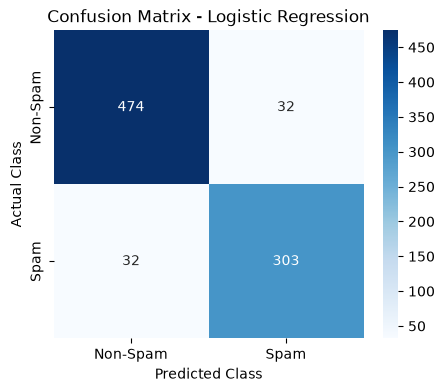

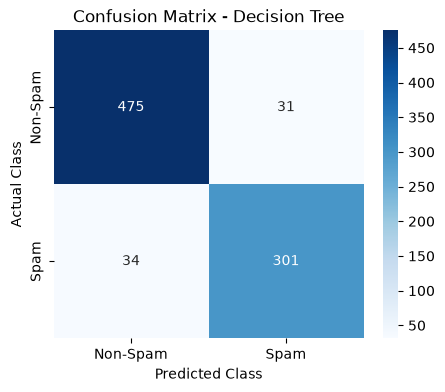

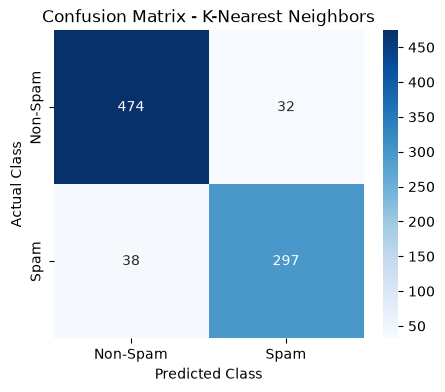

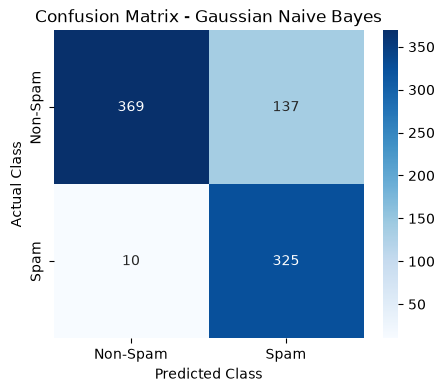

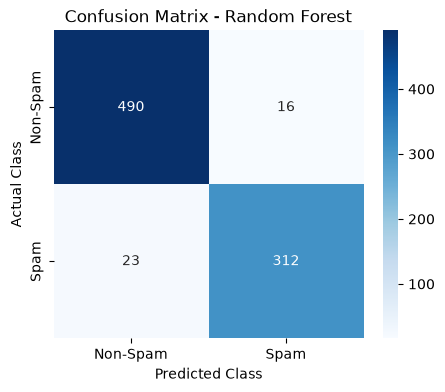

In [208]:
# ============================================================
# Confusion Matrices
# ============================================================

model_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "K-Nearest Neighbors": knn_pred,
    "Gaussian Naive Bayes": naive_bayes_pred,
    "Random Forest": random_forest_pred
}

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Spam", "Spam"],
        yticklabels=["Non-Spam", "Spam"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

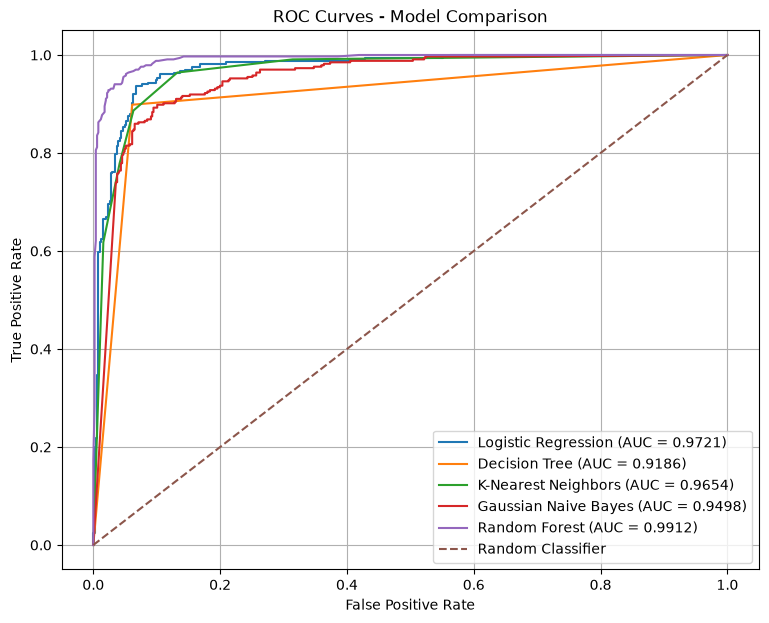

In [209]:
# ============================================================
# ROC Curves
# ============================================================

from sklearn.metrics import roc_curve

model_probabilities = {
    "Logistic Regression": logistic_prob,
    "Decision Tree": decision_tree_prob,
    "K-Nearest Neighbors": knn_prob,
    "Gaussian Naive Bayes": naive_bayes_prob,
    "Random Forest": random_forest_prob
}

plt.figure(figsize=(9, 7))

for model_name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")

plt.legend()
plt.grid()

plt.show()

## ROC Curve and AUC Analysis

The ROC curves compare the ability of the five classification models to
distinguish between spam and non-spam emails across different
classification thresholds.

The diagonal dashed line represents a random classifier with an AUC of
0.5. A model with a curve closer to the top-left corner generally has
better classification performance.

Random Forest achieved the highest AUC of 0.9912, followed by Logistic
Regression (0.9721), K-Nearest Neighbors (0.9654), Gaussian Naive Bayes
(0.9498), and Decision Tree (0.9186).

The Random Forest ROC curve is closest to the top-left corner and
demonstrates excellent class-separation ability.

An interesting observation is that Gaussian Naive Bayes achieves a
relatively high AUC of 0.9498 despite having a lower accuracy of 82.52%.
This occurs because AUC evaluates the model's ranking ability across
different classification thresholds, whereas accuracy and the other
classification metrics are calculated using a specific classification
threshold.

Overall, the ROC analysis further supports Random Forest as the strongest
overall model for the Spambase classification problem.

In [210]:
# ============================================================
# Classification Reports
# ============================================================

for model_name, predictions in model_predictions.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["Non-Spam", "Spam"],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    Non-Spam       0.94      0.94      0.94       506
        Spam       0.90      0.90      0.90       335

    accuracy                           0.92       841
   macro avg       0.92      0.92      0.92       841
weighted avg       0.92      0.92      0.92       841

Decision Tree
              precision    recall  f1-score   support

    Non-Spam       0.93      0.94      0.94       506
        Spam       0.91      0.90      0.90       335

    accuracy                           0.92       841
   macro avg       0.92      0.92      0.92       841
weighted avg       0.92      0.92      0.92       841

K-Nearest Neighbors
              precision    recall  f1-score   support

    Non-Spam       0.93      0.94      0.93       506
        Spam       0.90      0.89      0.89       335

    accuracy                           0.92       841
   macro avg       0.91      0.91      0.91       841
weighted avg       0

In [211]:
# ============================================================
# Confusion Matrix Values for All Models
# ============================================================

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("                Predicted")
    print("              Non-Spam   Spam")
    print(f"Actual Non-Spam   {cm[0,0]:4d}     {cm[0,1]:4d}")
    print(f"Actual Spam       {cm[1,0]:4d}     {cm[1,1]:4d}")


Logistic Regression
                Predicted
              Non-Spam   Spam
Actual Non-Spam    474       32
Actual Spam         32      303

Decision Tree
                Predicted
              Non-Spam   Spam
Actual Non-Spam    475       31
Actual Spam         34      301

K-Nearest Neighbors
                Predicted
              Non-Spam   Spam
Actual Non-Spam    474       32
Actual Spam         38      297

Gaussian Naive Bayes
                Predicted
              Non-Spam   Spam
Actual Non-Spam    369      137
Actual Spam         10      325

Random Forest
                Predicted
              Non-Spam   Spam
Actual Non-Spam    490       16
Actual Spam         23      312


## Confusion Matrix Analysis

The confusion matrices show that Random Forest provides the best
overall balance between false positives and false negatives.

Random Forest produced only 16 false positives and 23 false negatives,
which were the lowest false-positive count and a relatively low
false-negative count among the evaluated models.

Gaussian Naive Bayes achieved the highest recall of 97.01% and produced
only 10 false negatives. However, it generated 137 false positives,
which substantially reduced its precision to 70.35%.

Logistic Regression, Decision Tree and KNN produced relatively balanced
false-positive and false-negative counts, but their overall performance
was lower than Random Forest.

Therefore, Random Forest provides the best overall trade-off between
identifying spam emails and avoiding incorrect classification of
legitimate emails.

# 19. Save All Trained Models

All five trained classification models are saved so that they can be
loaded by the Streamlit application without retraining.

Logistic Regression and K-Nearest Neighbors were trained using
standardized features, so the fitted StandardScaler is saved together
with these models.

Decision Tree, Gaussian Naive Bayes, and Random Forest were trained using
the original unscaled features and therefore do not require a scaler.

The feature names are also saved with each model to ensure that the
uploaded test data in the Streamlit application has the correct
structure.

In [212]:
# ============================================================
# Save Logistic Regression
# ============================================================

logistic_bundle = {
    "model": logistic_model,
    "scaler": scaler,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    logistic_bundle,
    "../model/logistic_regression.pkl"
)

print("Logistic Regression saved successfully.")

Logistic Regression saved successfully.


In [213]:
# ============================================================
# Save Decision Tree
# ============================================================

decision_tree_bundle = {
    "model": decision_tree_model,
    "scaler": None,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    decision_tree_bundle,
    "../model/decision_tree.pkl"
)

print("Decision Tree saved successfully.")

Decision Tree saved successfully.


In [214]:
# ============================================================
# Save K-Nearest Neighbors
# ============================================================

knn_bundle = {
    "model": knn_model,
    "scaler": scaler,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    knn_bundle,
    "../model/knn.pkl"
)

print("KNN saved successfully.")

KNN saved successfully.


In [215]:
# ============================================================
# Save Gaussian Naive Bayes
# ============================================================

naive_bayes_bundle = {
    "model": naive_bayes_model,
    "scaler": None,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    naive_bayes_bundle,
    "../model/gaussian_naive_bayes.pkl"
)

print("Gaussian Naive Bayes saved successfully.")

Gaussian Naive Bayes saved successfully.


In [216]:
# ============================================================
# Save Random Forest
# ============================================================

random_forest_bundle = {
    "model": random_forest_model,
    "scaler": None,
    "feature_names": X.columns.tolist()
}

joblib.dump(
    random_forest_bundle,
    "../model/random_forest.pkl"
)

print("Random Forest saved successfully.")

Random Forest saved successfully.


In [217]:
# ============================================================
# Create Test Dataset for Streamlit
# ============================================================

test_data = X_test.copy()

test_data["spam"] = y_test.values

print("Test data shape:", test_data.shape)

test_data.head()

Test data shape: (841, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
2351,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.00,...,0.0,0.000,0.000,0.000,0.000,0.395,2.333,8,119,0
3519,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.00,...,0.0,0.000,0.374,0.000,0.000,0.000,1.583,8,19,0
2439,0.21,0.00,0.21,0.21,0.63,0.0,0.00,0.0,0.0,0.00,...,0.0,0.031,0.000,0.374,0.062,0.000,2.892,71,405,0
2235,0.00,2.12,0.00,0.00,0.00,0.0,0.00,0.0,0.0,2.12,...,0.0,0.000,0.000,0.000,0.000,0.000,1.300,4,13,0
1009,0.48,0.00,0.97,0.00,0.48,0.0,0.97,0.0,0.0,0.00,...,0.0,0.000,0.000,1.085,0.232,0.077,5.166,58,186,1


In [218]:
# ============================================================
# Save Test Data
# ============================================================

test_data.to_csv(
    "../test_data.csv",
    index=False
)

print("test_data.csv created successfully.")
print("Shape:", test_data.shape)

test_data.csv created successfully.
Shape: (841, 58)


In [219]:
# ============================================================
# Verify Saved Models
# ============================================================

import joblib

model_files = {
    "Logistic Regression": "../model/logistic_regression.pkl",
    "Decision Tree": "../model/decision_tree.pkl",
    "KNN": "../model/knn.pkl",
    "Gaussian Naive Bayes": "../model/gaussian_naive_bayes.pkl",
    "Random Forest": "../model/random_forest.pkl"
}

for model_name, model_path in model_files.items():

    bundle = joblib.load(model_path)

    model = bundle["model"]
    saved_scaler = bundle["scaler"]

    if saved_scaler is not None:
        test_features = saved_scaler.transform(X_test)
    else:
        test_features = X_test

    predictions = model.predict(test_features)

    accuracy = accuracy_score(y_test, predictions)

    print(f"{model_name}: Accuracy = {accuracy:.4f}")

Logistic Regression: Accuracy = 0.9239
Decision Tree: Accuracy = 0.9227
KNN: Accuracy = 0.9168
Gaussian Naive Bayes: Accuracy = 0.8252
Random Forest: Accuracy = 0.9536


In [ ]:
import sklearn
import pandas
import numpy
import joblib
import streamlit
import matplotlib
import seaborn

print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)
print("streamlit:", streamlit.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)